In [ ]:
%gui tk
import tkinter as tk
from tkinter import ttk, messagebox
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Creating the main window for gui
window = tk.Tk()
window.title("Data management system")
window.geometry("275x350")
frame1 = ttk.Frame(window, padding="10")
frame1.grid(column=0, row=0, sticky=(tk.W, tk.E, tk.N, tk.S))
frame2 = ttk.Frame(window)
frame1.grid(column=0, row=0, sticky=(tk.W, tk.E, tk.N, tk.S))
# Welcome message
title = ttk.Label(frame1, text="Welcome to data management system")
title.grid(column=0, row=0, columnspan=2, pady=10)

In [ ]:
# Variables for frame 1

feedback = ttk.Label(frame1, text="", foreground="black") 
feedback.grid(column=1, row=6, columnspan=2) 

data_loaded = False
data_cleaned = False
activity = None
component = None
user = None

In [ ]:
# Variables for frame 2

feedback2 = ttk.Label(frame2, text="", foreground="black") 
feedback2.grid(column=0, row=8, columnspan=2)

is_pivoted = False
is_counted = False

In [ ]:
def load_data():
    global data_loaded, feedback, activity, component, user
    if data_loaded:
        messagebox.showwarning("Load data", "Data is already loaded!")
        return
    try:
        activity = pd.read_csv("ACTIVITY_LOG.csv")
        component = pd.read_csv("COMPONENT_CODES.csv") 
        user = pd.read_csv("USER_LOG.csv")
        data_loaded = True
        feedback.config(text="Data has been loaded successfully", foreground="green")
    except FileNotFoundError as e:
        feedback.config(text="File not found. Check the location of the file", foreground="red")
    except Exception as e:
        feedback.config(text="An error has occurred", foreground="red")

In [ ]:
def clean_data():
    global data_loaded, feedback, data_cleaned
    if data_loaded == True and data_cleaned == True:
        messagebox.showwarning("Clean data", "Data is already cleaned and saved!")
    if data_loaded:
        clean_save()
        data_cleaned = True
        feedback.config(text="Data has been cleaned successfully.", foreground="green")
        feedback_final = ttk.Label(frame1, text="Data has been cleaned and saved. \n If you wish to do any other data manipulation, press 'Continue'!", 
                                          wraplength=200)
        feedback_final.grid(column=1, row=8, columnspan=2)    
    elif data_loaded == False:
        feedback.config(text="Please load the data first", foreground="red")

In [ ]:
def clean_save():
    global  activity, component, user, final_df
    #Rename "User Full Name *Anonymized" to USER_ID
    try:
        activity = activity.rename(columns={'User Full Name *Anonymized': 'USER_ID'})
        user = user.rename(columns={'User Full Name *Anonymized': 'USER_ID'})

    # Merging datasets
        acti_comp = pd.merge(activity, component, on='Component', how='left')
        acti_comp.set_index('USER_ID', inplace=True)
        user.set_index('USER_ID', inplace=True)
        final_df = pd.concat([acti_comp, user], axis=1)  # Concatenating remaining files
        final_df.reset_index(inplace=True)

    # Combining together date and time 
        final_df.loc[:, 'DateTime'] = pd.to_datetime(final_df['Date'].str.split().str[0] + ' ' + final_df['Time'], format='%d/%m/%Y %H:%M:%S')
        final_df = final_df.drop(columns=['Date', 'Time'])
    
    # Removing components "System" and "Folder"
        final_df = final_df[~final_df['Component'].isin(['System', 'Folder'])]

    # Saving the file as Json
        final_df.to_json("Dataset.json", orient = "records")
        
    except Exception as e:
        feedback.config(text="An error has occurred while cleaning", foreground="red")
    

In [ ]:
def show_frame(frame2, frame1):
    frame1.grid_forget()
    frame2.grid(row=0, column=0, sticky="nsew")
    window.geometry("1200x500")

In [ ]:
# Creating frame1 buttons
loadCsvBtn = ttk.Button(frame1, text="Load the initial data", command=load_data, width=20)
loadCsvBtn.grid(column=1, row=1, padx=10, pady=5)

cleanBtn = ttk.Button(frame1, text="Clean and save", command=clean_data, width=20)
cleanBtn.grid(column=1, row=2, padx=10, pady=5)

continueBtn = ttk.Button(frame1, text="Continue", command=lambda: show_frame(frame2, frame1), width=20)
continueBtn.grid(column=1, row=3, padx=10, pady=5)

closeBtn = ttk.Button(frame1, text="Quit", command=window.destroy, width=20)
closeBtn.grid(column=1, row=4, padx=10, pady=5)

In [ ]:
def count():
    global feedback2, is_counted
    final_df = pd.read_json("Dataset.json", orient="records")
    if is_counted:
        messagebox.showwarning("Add count column", "Count column is already added!")
        return
    try:
        final_df['YearMonth'] = final_df['DateTime'].dt.to_period('M')  # Year-Month format
        counter = final_df.groupby(['USER_ID', 'Component', 'YearMonth']).size().reset_index(name='Count')
        final_df = final_df.merge(counter, on=['USER_ID', 'Component', 'YearMonth'], how='left')
        feedback2.config(text="Count column has been added successfully. \n Data has been saved.", foreground="green")
        is_counted = True
        # Saving the file with count column
        final_df['DateTime'] = final_df['DateTime'].astype(str)
        final_df['YearMonth'] = final_df['YearMonth'].astype(str)
        final_df.to_json("Dataset.json", orient="records")
    except Exception as e:
        feedback2.config(text="An error has occurred while counting", foreground="red")

In [ ]:
def pivot():
    global feedback2, is_pivoted
    final_df = pd.read_json("Dataset.json", orient="records")
    if is_pivoted:
        messagebox.showwarning("Pivot data", "Data is already pivoted!")
        return
    try:
        pivoted_df = final_df.pivot_table(
        index=['USER_ID'],    #add DateTime
        columns='Component',
        values=['Action','Target'],
        aggfunc='size',
        fill_value=0)
        feedback2.config(text="Data has been pivoted successfully.", foreground="green")
        is_pivoted = True
    except Exception as e:
        feedback2.config(text="An error has occurred while pivoting or loading", foreground="red")

In [ ]:
def correlate():
    global feedback2, is_counted
    if is_counted == False:
        feedback2.config(text="Please count the interactions for each user before attempting correlation!", foreground="red")
    elif is_counted:
        try:
            final_df = pd.read_json("Dataset.json", orient="records")
            components = ['Assignment', 'Quiz', 'Lecture', 'Book', 'Project', 'Course']
            filtered_df = final_df[final_df['Component'].isin(components)]
            pivoted_df = filtered_df.pivot_table(index='USER_ID', columns='Component', values='Count', aggfunc='sum')
            pivoted_df.fillna(0)
            corr_matrix = pivoted_df.corr()
            sns.heatmap(corr_matrix, annot=True, cmap='coolwarm') 
            plt.title("Correlation Heatmap for Components and Interaction Counts")
            plt.show()
        except: 
            feedback2.config(text="An error has occurred!", foreground="red")

In [ ]:
# Frame 2 data manipulation

# Count button 
countlbl = tk.Label(frame2, text="Click the button to count the interactions for each user with the component for each month.")
countlbl.grid(row=0, column=0, padx=10, pady=10, sticky="w")
countBtn = ttk.Button(frame2, text="Count", width=15, command=count)
countBtn.grid(row=1, column=0, padx=10, pady=5)

# Pivot button
pivotlbl = tk.Label(frame2, text="Click the button to reshape the data")
pivotlbl.grid(row=2, column=0, padx=10, pady=10, sticky="w")
pivotBtn = ttk.Button(frame2, text="Pivot", width=15, command=pivot)
pivotBtn.grid(row=3, column=0, padx=10, pady=5)

# Correlation button
corrlabel = tk.Label(frame2, text="Calculate correlation")
corrlabel.grid(row=4, column=0, padx=10, pady=10, sticky="w")
corrBtn = ttk.Button(frame2, text="Correlation", width=15, command=correlate)
corrBtn.grid(row=5, column=0, padx=10, pady=5)

# Combobox for outputs
statlabel = tk.Label(frame2, text="Pick which component you want to create the mean, mode and median.")
statlabel.grid(row=6, column=0, columnspan=3, padx=10, pady=10, sticky="w")
stat = ttk.Combobox(frame2, width=25)
stat["values"] = ("Quiz", "Lecture", "Assignment", "Attendance", "Survey")
stat.set("Select an option for statistics")
stat.grid(row=7, column=0, columnspan=3, padx=10, pady=10) 


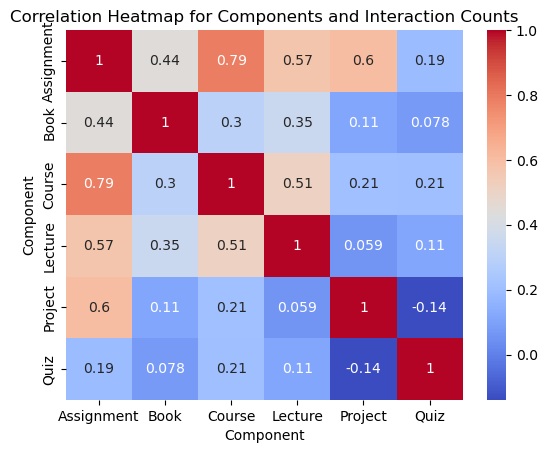

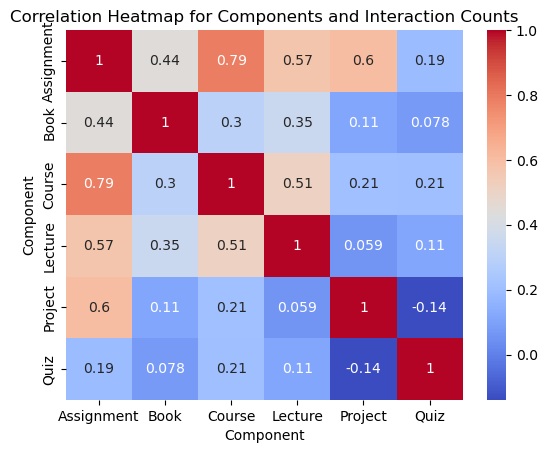

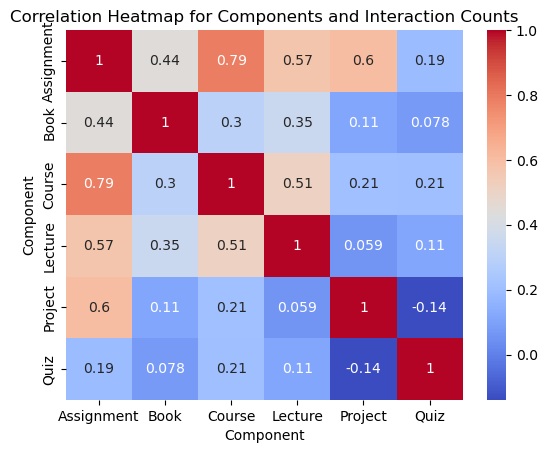

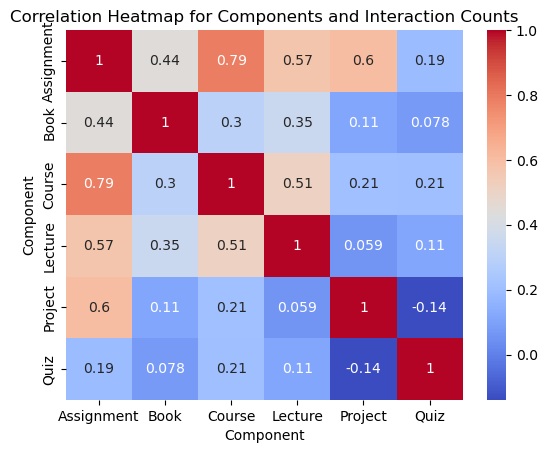

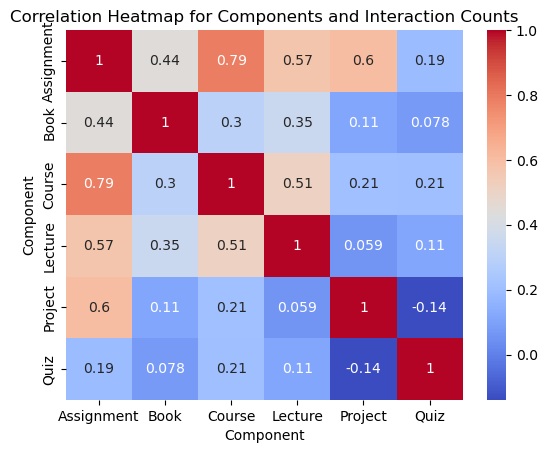

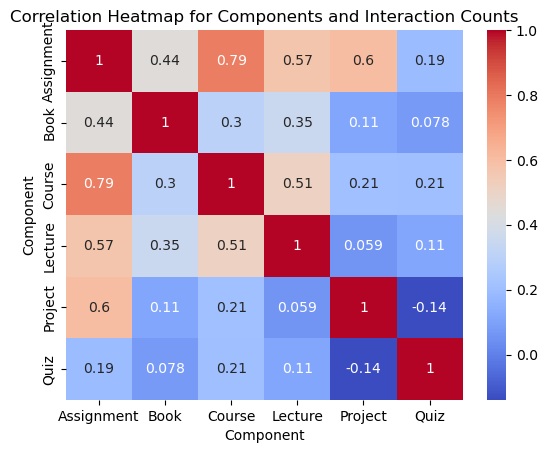

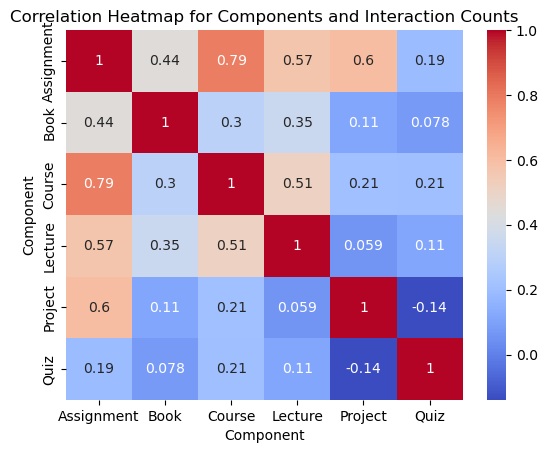

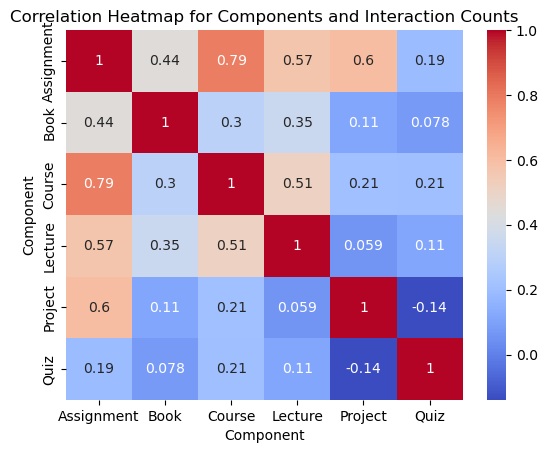

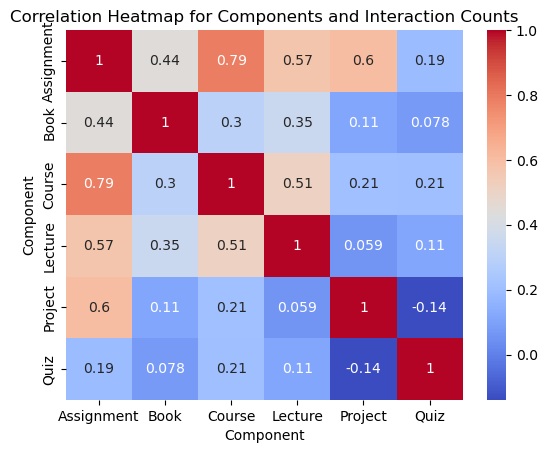

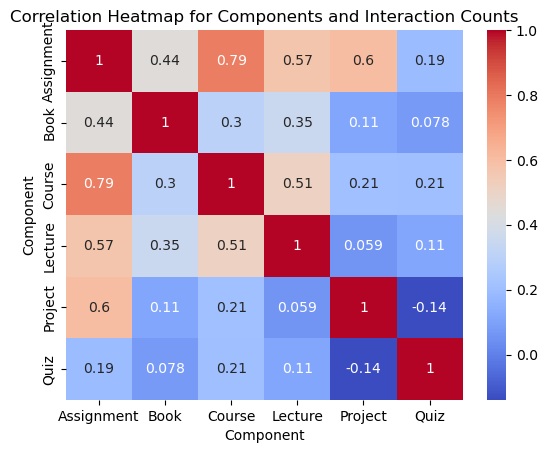

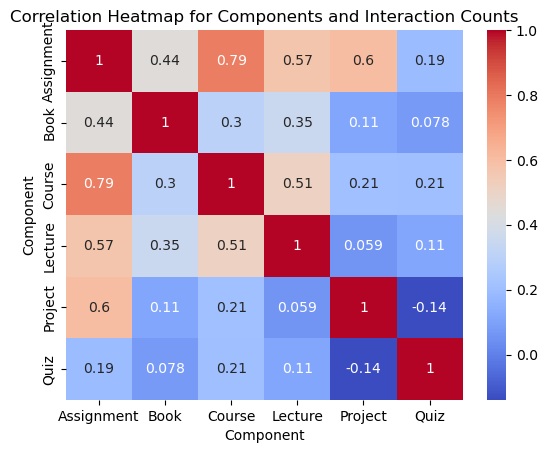

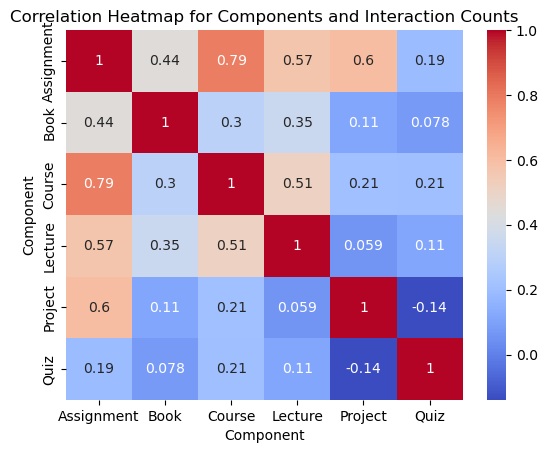

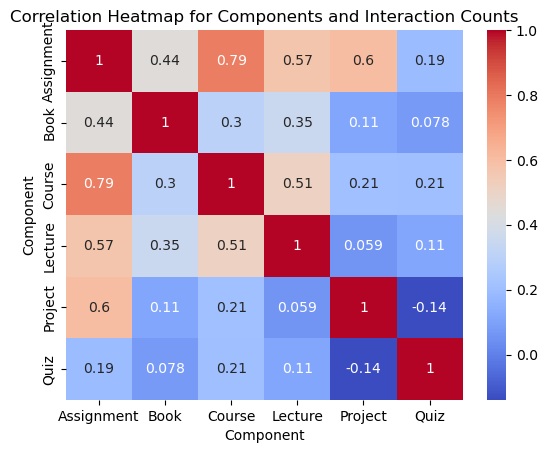

In [ ]:
window.mainloop()